In [1]:
import os
import re
import requests
import pandas as pd

try:
    from config import API_KEYS
except ModuleNotFoundError:
    API_KEYS = {}


# 지하철역 주소

## 1. 데이터 불러오기 및 데이터 확인

In [2]:
df_raw = pd.read_csv(
    "/Users/danha/Desktop/IT/project/team_project_brew_map/data/station.csv",
    encoding="cp949"
)

print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
df_raw.head()

Shape: (289, 4)
Columns: ['idx', 'line', 'station', 'address']


,idx,line,station,address
0,1,1호선,서울,서울특별시 중구 세종대로 지하2(남대문로 5가)
1,2,1호선,시청,서울특별시 중구 세종대로 지하101(정동)
2,3,1호선,종각,서울특별시 종로구 종로 지하55(종로1가)
3,4,1호선,종로3가,서울특별시 종로구 종로 지하129(종로3가)
4,5,1호선,종로5가,서울특별시 종로구 종로 지하216(종로5가)


In [3]:
print('=== 데이터 타입 ===')
print(df_raw.dtypes)
print()
print('=== 결측값 현황 ===')
print(df_raw.isnull().sum())
print()
print('=== 중복값 현황 ===')
print("전체 행 수:", len(df_raw))
print("완전 중복 행 수:", df_raw.duplicated().sum())

=== 데이터 타입 ===
idx         int64
line       object
station    object
address    object
dtype: object

=== 결측값 현황 ===
idx        0
line       0
station    0
address    0
dtype: int64

=== 중복값 현황 ===
전체 행 수: 289
완전 중복 행 수: 0


## 2. 카카오맵 API를 이용하여 주소 정제 및 위경도 좌표 찾기

카카오지도 REST API 키 발급 후 카카오맵 사용설정 상태 ON 

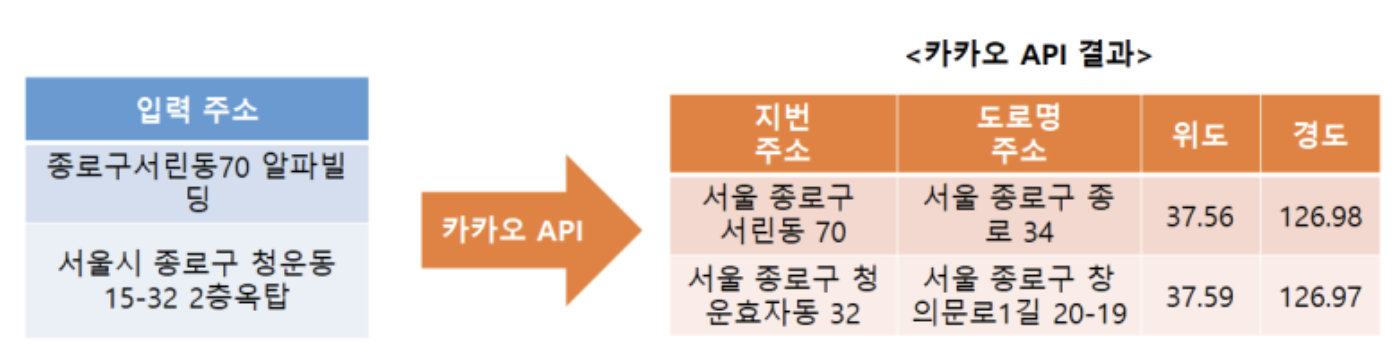

In [14]:
kakao_key  = os.getenv("KAKAO_REST_KEY")


### 2.1 API 테스트

In [ ]:
url = "	https://dapi.kakao.com/v2/local/search/address.json" #요청할 url 주소
headers = {"Authorization": f"KakaoAK REST API 키"} #REST API 키
params = {"query": "성수동2가 269-25"}  # 입력할 주소
resp = requests.get(url,headers=headers, params=params).json() #카카오 API 요청
                      
print(resp) #API 결과 출력
resp['documents'][0]['road_address']

{'documents': [{'address': {'address_name': '서울 성동구 성수동2가 269-25', 'b_code': '1120011500', 'h_code': '1120067000', 'main_address_no': '269', 'mountain_yn': 'N', 'region_1depth_name': '서울', 'region_2depth_name': '성동구', 'region_3depth_h_name': '성수2가1동', 'region_3depth_name': '성수동2가', 'sub_address_no': '25', 'x': '127.056741837461', 'y': '37.5402196364231'}, 'address_name': '서울 성동구 성수동2가 269-25', 'address_type': 'REGION_ADDR', 'road_address': {'address_name': '서울 성동구 성수이로10길 14', 'building_name': '에이스 하이엔드 성수타워', 'main_building_no': '14', 'region_1depth_name': '서울', 'region_2depth_name': '성동구', 'region_3depth_name': '성수동2가', 'road_name': '성수이로10길', 'sub_building_no': '', 'underground_yn': 'N', 'x': '127.056789858953', 'y': '37.5401307747523', 'zone_no': '04784'}, 'x': '127.056741837461', 'y': '37.5402196364231'}], 'meta': {'is_end': True, 'pageable_count': 1, 'total_count': 1}}


{'address_name': '서울 성동구 성수이로10길 14',
 'building_name': '에이스 하이엔드 성수타워',
 'main_building_no': '14',
 'region_1depth_name': '서울',
 'region_2depth_name': '성동구',
 'region_3depth_name': '성수동2가',
 'road_name': '성수이로10길',
 'sub_building_no': '',
 'underground_yn': 'N',
 'x': '127.056789858953',
 'y': '37.5401307747523',
 'zone_no': '04784'}

### 2.2 전체 주소 카카오 API 호출

In [ ]:
url = "	https://dapi.kakao.com/v2/local/search/address.json" #요청할 url 주소
headers = {"Authorization": f"KakaoAK REST API 키"} #REST API 키

for idx, add in df_raw['address'].items():
    params = {"query": add}
    resp = requests.get(url, headers=headers, params=params).json()

    docs = resp.get('documents', [])
    if not docs:
        continue

    road = docs[0].get('road_address')  # 없을 수도 있음

    if road:
        df_raw.loc[idx, 'road_address'] = road.get('address_name')
        df_raw.loc[idx, 'lat'] = road.get('y') # Y 좌표값, 경위도인 경우 위도(latitude)
        df_raw.loc[idx, 'lng'] = road.get('x') # X 좌표값, 경위도인 경우 경도(longitude)
    else:
        # road_address가 없으면 지번주소(address) 기준으로라도 좌표 저장
        addr = docs[0].get('address')
        if addr:
            df_raw.loc[idx, 'road_address'] = addr.get('address_name')
            df_raw.loc[idx, 'lat'] = addr.get('y')
            df_raw.loc[idx, 'lng'] = addr.get('x')

df_raw

,idx,line,station,address,road_address,lat,lng
0,1,1호선,서울,서울특별시 중구 세종대로 지하2(남대문로 5가),서울 중구 세종대로 지하 2,37.5571594835988,126.972554606456
1,2,1호선,시청,서울특별시 중구 세종대로 지하101(정동),서울 중구 세종대로 지하 101,37.5654385176408,126.976983237511
2,3,1호선,종각,서울특별시 종로구 종로 지하55(종로1가),서울 종로구 종로 지하 55,37.5702140381269,126.983239678933
3,4,1호선,종로3가,서울특별시 종로구 종로 지하129(종로3가),서울 종로구 종로 지하 129,37.5704266025836,126.99202930223
4,5,1호선,종로5가,서울특별시 종로구 종로 지하216(종로5가),서울 종로구 종로 지하 216,37.5709075371016,127.001916647342
...,...,...,...,...,...,...,...
284,285,9호선,송파나루,서울특별시 송파구 백제고분로 지하446(방이동),서울 송파구 백제고분로 지하 446,37.5106316985927,127.112393866995
285,286,9호선,한성백제,서울특별시 송파구 위례성대로 지하29(방이동),서울 송파구 위례성대로 지하 29,37.5164647953901,127.116303251765
286,287,9호선,올림픽공원(한국체대),서울특별시 송파구 양재대로 지하1233(방이동),서울 송파구 양재대로 지하 1233,37.5160876492782,127.130600140827
287,288,9호선,둔촌오륜,서울특별시 강동구 강동대로 지하303(둔촌동),서울 강동구 강동대로 지하 303,37.5194090259388,127.138423684558


## 3. 결측치

### 3.1 서울 여부 체크

In [7]:
total = len(df_raw)

seoul_cnt = df_raw['road_address'].str.contains('서울', na=False).sum()
na_cnt = df_raw['road_address'].isna().sum() #결측개수
not_seoul_only = total - seoul_cnt - na_cnt

print("전체:", total)
print("서울:", seoul_cnt)
print("서울 외:", not_seoul_only)
print("결측:", na_cnt)

전체: 289
서울: 273
서울 외: 15
결측: 1


### 3.2 결측 제거

In [8]:
# 제거 전 행 수 저장
before = len(df_raw)

# 서울 주소만 남기기 (서울 외 + 결측 자동 제거)
df_raw = df_raw[
    df_raw['road_address'].str.contains('서울', na=False)
]

after = len(df_raw)

print("=== 필터링 결과 ===")
print("제거된 행 수:", before - after)
print("최종 행 수:", after)

=== 필터링 결과 ===
제거된 행 수: 16
최종 행 수: 273


## 4. idx 재설정 및 정렬

In [11]:
df_raw.sort_values(by = 'idx', inplace=True)
df_raw['idx'] = range(1, len(df_raw) + 1) # idx 번호 재부여
df_raw.reset_index(drop=True, inplace=True) # index 재설정
df_raw

/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_43516/1719597356.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_raw.sort_values(by = 'idx', inplace=True)
/var/folders/hr/fhwqrjln55v6pjpz2zxrtw840000gn/T/ipykernel_43516/1719597356.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_raw['idx'] = range(1, len(df_raw) + 1) # idx 번호 재부여


,idx,line,station,address,road_address,lat,lng
0,1,1호선,서울,서울특별시 중구 세종대로 지하2(남대문로 5가),서울 중구 세종대로 지하 2,37.5571594835988,126.972554606456
1,2,1호선,시청,서울특별시 중구 세종대로 지하101(정동),서울 중구 세종대로 지하 101,37.5654385176408,126.976983237511
2,3,1호선,종각,서울특별시 종로구 종로 지하55(종로1가),서울 종로구 종로 지하 55,37.5702140381269,126.983239678933
3,4,1호선,종로3가,서울특별시 종로구 종로 지하129(종로3가),서울 종로구 종로 지하 129,37.5704266025836,126.99202930223
4,5,1호선,종로5가,서울특별시 종로구 종로 지하216(종로5가),서울 종로구 종로 지하 216,37.5709075371016,127.001916647342
...,...,...,...,...,...,...,...
268,269,9호선,송파나루,서울특별시 송파구 백제고분로 지하446(방이동),서울 송파구 백제고분로 지하 446,37.5106316985927,127.112393866995
269,270,9호선,한성백제,서울특별시 송파구 위례성대로 지하29(방이동),서울 송파구 위례성대로 지하 29,37.5164647953901,127.116303251765
270,271,9호선,올림픽공원(한국체대),서울특별시 송파구 양재대로 지하1233(방이동),서울 송파구 양재대로 지하 1233,37.5160876492782,127.130600140827
271,272,9호선,둔촌오륜,서울특별시 강동구 강동대로 지하303(둔촌동),서울 강동구 강동대로 지하 303,37.5194090259388,127.138423684558


In [13]:
# 전처리 완료 데이터 저장

save_path = "/Users/danha/Desktop/IT/project/team_project_brew_map/data/dh/station.csv"

df_raw.to_csv(save_path, index=False, encoding="utf-8-sig")

print("저장 완료:", save_path)

저장 완료: /Users/danha/Desktop/IT/project/team_project_brew_map/data/dh/station.csv
